# 03 Data Audit and Manifest Preparation — G1020, REFUGE, PAPILA

Extends the manifest pipeline to the remaining segmentation datasets, following
the same pattern as `01_data_audit_and_manifest.ipynb` (image–mask pairing by
file id, visual QA on a sample, a structured manifest CSV per source with the
identical schema as ORIGA).

Two source-specific notes:
- **REFUGE** ships official `train`/`val`/`test` folders; we pair within each and
  record the official split as a column so it can be honored later.
- **PAPILA** stores ground truth as per-expert polygon contours, not raster masks.
  We rasterize them into `{0,1,2}` PNGs under `data/processed/papila_masks/` so
  `mask_path` points to a real file like every other source. Split grouping is by
  patient (both eyes together) and is handled in the split notebook.

In [2]:
from pathlib import Path
import sys, os
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def find_project_root(start_path: Path | None = None) -> Path:
    start_path = start_path or Path.cwd()
    for path in [start_path, *start_path.parents]:
        if (path / "configs").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing configs/ and src/")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

BUNDLE_REL = "data/external/kaggle/glaucoma_fundus_imaging_bundle"
PAPILA_REL = "data/external/kaggle/papila"
MANIFEST_DIR = PROJECT_ROOT / "data" / "processed" / "manifests"
REPORT_DIR = PROJECT_ROOT / "reports" / "data_audit"
PAPILA_MASK_DIR = PROJECT_ROOT / "data" / "processed" / "papila_masks"
for d in (MANIFEST_DIR, REPORT_DIR, PAPILA_MASK_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
MANIFEST_COLUMNS = [
    "dataset_key", "source_dataset", "file_id", "image_path", "mask_path",
    "image_relative_path", "mask_relative_path", "image_file_name", "mask_file_name",
    "mask_encoding", "background_value", "structure_value_1", "structure_value_2",
    "split_group_id", "include_in_first_pass", "qa_status", "notes",
]

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/tylerhobbs/Documents/Virginia/Glaucoma Project


## Shared helpers — pairing, manifest assembly, visual QA

In [3]:
def list_stems(folder: Path):
    if not folder.exists():
        return {}
    return {p.stem: p for p in folder.iterdir() if p.suffix.lower() in IMG_EXT}

def pair_image_mask(image_dir: Path, mask_dir: Path):
    """Pair by filename stem (id). Returns paired list + unpaired counts."""
    imgs, masks = list_stems(image_dir), list_stems(mask_dir)
    paired = sorted(set(imgs) & set(masks))
    rows = [{"file_id": s, "image_abs": imgs[s], "mask_abs": masks[s]} for s in paired]
    return rows, {"n_images": len(imgs), "n_masks": len(masks),
                  "n_pairs": len(paired), "n_unpaired": len(set(imgs) ^ set(masks))}

def manifest_row(source, file_id, image_abs, mask_abs, split_group_id, notes, qa_status, extra=None):
    image_rel_proj = Path(image_abs).resolve().relative_to(PROJECT_ROOT).as_posix()
    mask_rel_proj = Path(mask_abs).resolve().relative_to(PROJECT_ROOT).as_posix()
    row = {
        "dataset_key": "glaucoma_fundus_imaging_bundle" if source != "PAPILA" else "papila",
        "source_dataset": source, "file_id": str(file_id),
        "image_path": image_rel_proj, "mask_path": mask_rel_proj,
        "image_relative_path": image_rel_proj,
        "mask_relative_path": mask_rel_proj,
        "image_file_name": Path(image_abs).name, "mask_file_name": Path(mask_abs).name,
        "mask_encoding": "multiclass_values_0_1_2",
        "background_value": 0, "structure_value_1": 1, "structure_value_2": 2,
        "split_group_id": split_group_id, "include_in_first_pass": True,
        "qa_status": qa_status, "notes": notes,
    }
    if extra:
        row.update(extra)
    return row

def visual_qa(manifest_df, source, n=4):
    """Sample, overlay mask on image, print unique values, save a QA summary CSV."""
    smp = manifest_df.sample(n=min(n, len(manifest_df)), random_state=42).reset_index(drop=True)
    rows = []
    fig, ax = plt.subplots(len(smp), 3, figsize=(11, 3.2 * len(smp)))
    if len(smp) == 1:
        ax = ax[None, :]
    for i, r in smp.iterrows():
        img = Image.open(PROJECT_ROOT / r["image_path"]).convert("RGB")
        msk = np.asarray(Image.open(PROJECT_ROOT / r["mask_path"]))
        if msk.ndim == 3:
            msk = msk[..., 0]
        uniq = sorted(np.unique(msk).tolist())
        rows.append({"file_id": r["file_id"], "image_size": img.size,
                     "mask_shape": msk.shape, "sizes_match": img.size == msk.shape[::-1],
                     "mask_unique_values": uniq})
        ai = np.array(img.resize(msk.shape[::-1]))
        ax[i, 0].imshow(ai); ax[i, 0].set_title(f"{source} {r['file_id']}")
        ax[i, 1].imshow(msk); ax[i, 1].set_title(f"mask {uniq}")
        ax[i, 2].imshow(ai); ax[i, 2].imshow(msk, alpha=0.4); ax[i, 2].set_title("overlay")
        for a in ax[i]:
            a.axis("off")
    plt.tight_layout(); plt.show()
    qa = pd.DataFrame(rows)
    qa.to_csv(REPORT_DIR / f"{source.lower()}_visual_qa_summary.csv", index=False)
    return qa

## G1020 — pair `Images` ↔ `Masks`, build manifest

G1020 pairing: {'n_images': 1020, 'n_masks': 1020, 'n_pairs': 1020, 'n_unpaired': 0}
G1020 manifest rows: 1020


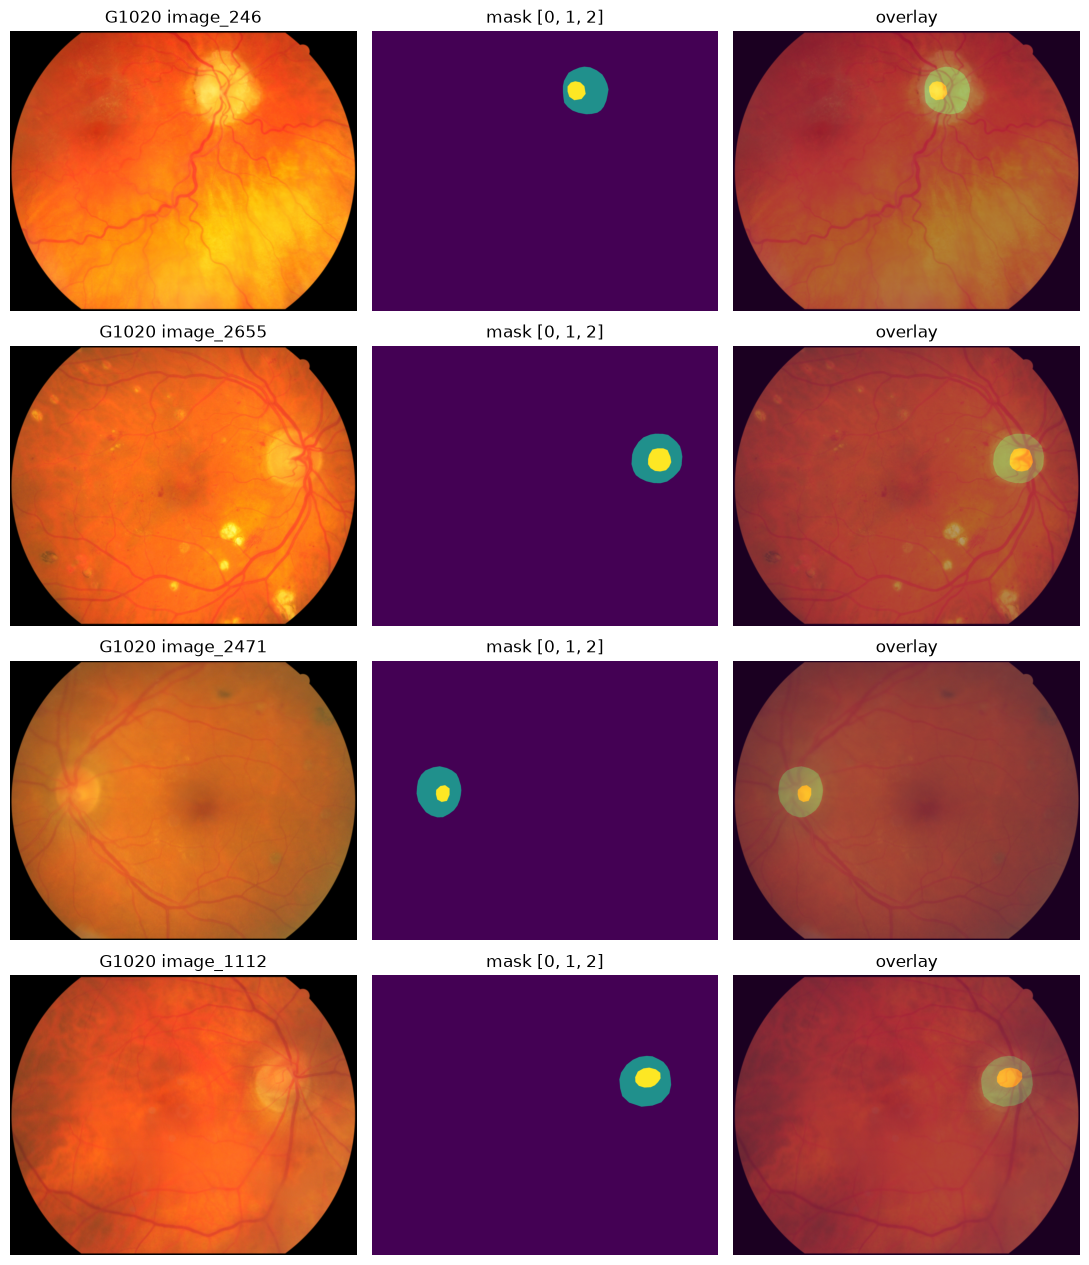

In [4]:
g_rows, g_stats = pair_image_mask(PROJECT_ROOT / BUNDLE_REL / "G1020/Images",
                                  PROJECT_ROOT / BUNDLE_REL / "G1020/Masks")
print("G1020 pairing:", g_stats)
g1020_manifest = pd.DataFrame([
    manifest_row("G1020", r["file_id"], r["image_abs"], r["mask_abs"],
                 split_group_id=f"G1020_{r['file_id']}",
                 qa_status="paired_and_visual_sample_reviewed",
                 notes="G1020 raw Images/Masks paired on file id; masks encoded {0,1,2}.")
    for r in g_rows
])[MANIFEST_COLUMNS]
g1020_manifest.to_csv(MANIFEST_DIR / "g1020_segmentation_manifest.csv", index=False)
print("G1020 manifest rows:", len(g1020_manifest))
visual_qa(g1020_manifest, "G1020");

## REFUGE — pair within official `train`/`val`/`test`, record official split

REFUGE/train pairing: {'n_images': 400, 'n_masks': 400, 'n_pairs': 400, 'n_unpaired': 0}
REFUGE/val pairing: {'n_images': 400, 'n_masks': 400, 'n_pairs': 400, 'n_unpaired': 0}
REFUGE/test pairing: {'n_images': 400, 'n_masks': 400, 'n_pairs': 400, 'n_unpaired': 0}
REFUGE manifest rows: 1200


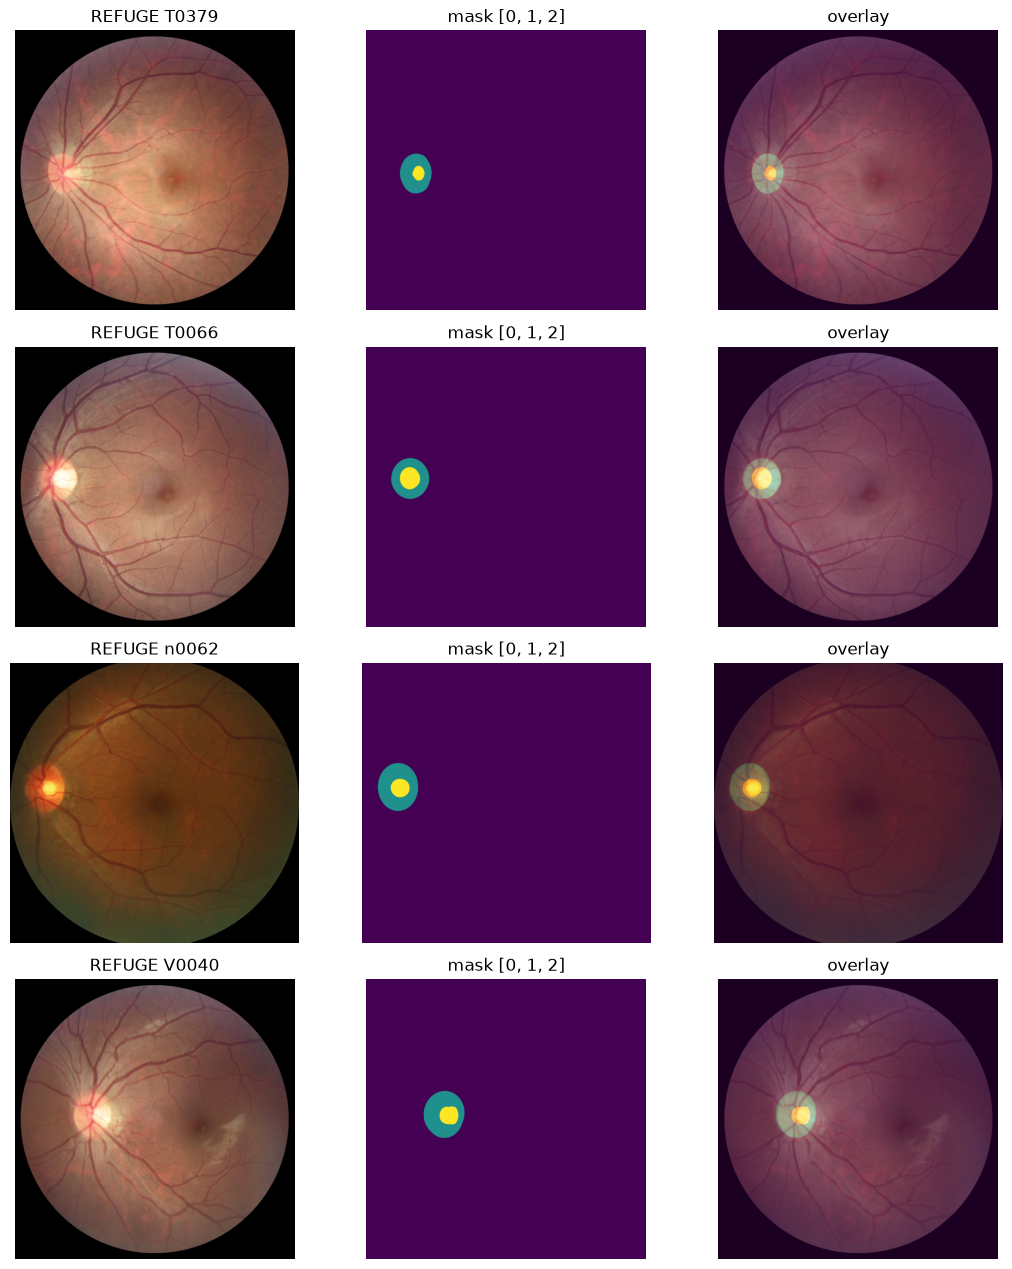

In [5]:
refuge_records = []
for official in ("train", "val", "test"):
    rows, stats = pair_image_mask(PROJECT_ROOT / BUNDLE_REL / f"REFUGE/{official}/Images",
                                  PROJECT_ROOT / BUNDLE_REL / f"REFUGE/{official}/Masks")
    print(f"REFUGE/{official} pairing:", stats)
    for r in rows:
        rec = manifest_row("REFUGE", r["file_id"], r["image_abs"], r["mask_abs"],
                           split_group_id=f"REFUGE_{official}_{r['file_id']}",
                           qa_status="paired_and_visual_sample_reviewed",
                           notes="REFUGE raw Images/Masks paired on file id; masks encoded {0,1,2}.",
                           extra={"refuge_official_split": official})
        refuge_records.append(rec)
refuge_manifest = pd.DataFrame(refuge_records)[MANIFEST_COLUMNS + ["refuge_official_split"]]
refuge_manifest.to_csv(MANIFEST_DIR / "refuge_segmentation_manifest.csv", index=False)
print("REFUGE manifest rows:", len(refuge_manifest))
visual_qa(refuge_manifest, "REFUGE");

## PAPILA — rasterize per-expert contours into `{0,1,2}` masks, then build manifest

`EXPERT = 1` by default (both annotators are available). Split grouping by patient
(`RETxxx` across `OD`/`OS`) is applied in the split notebook.

PAPILA: rasterized 488 masks (skipped 0 missing a contour)
PAPILA manifest rows: 488


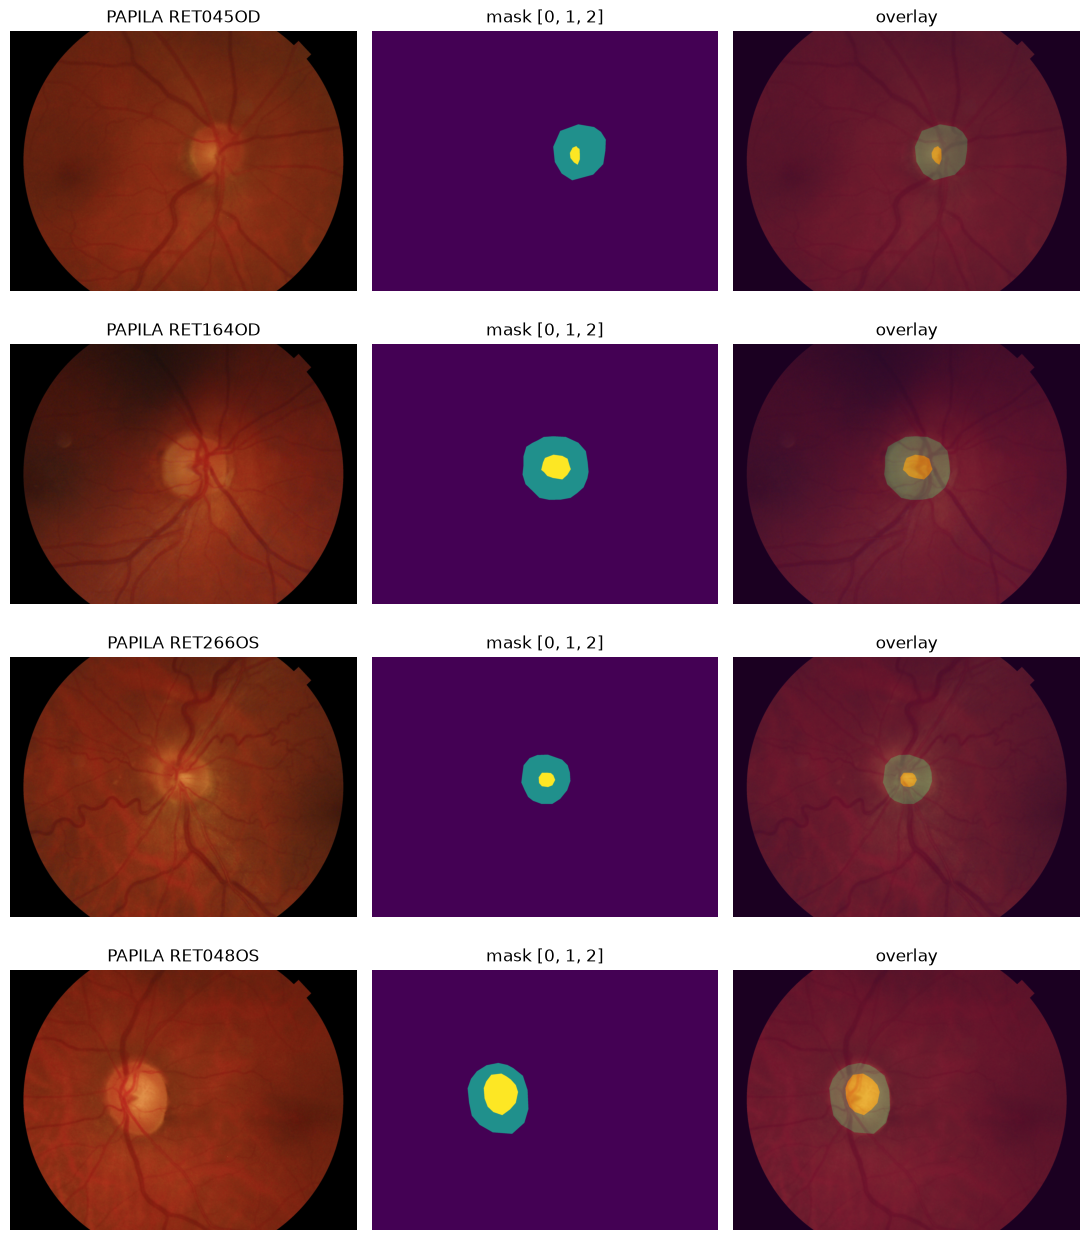

In [6]:
EXPERT = 1

def read_contour(path):
    pts = []
    with open(path, errors="replace") as f:
        for line in f:
            p = line.split()
            if len(p) >= 2:
                try:
                    pts.append((float(p[0]), float(p[1])))
                except ValueError:
                    pass
    return pts

def fill_polygon(points, h, w):
    canvas = Image.new("L", (w, h), 0)
    if len(points) >= 3:
        ImageDraw.Draw(canvas).polygon(points, outline=1, fill=1)
    return np.asarray(canvas, dtype=bool)

papila_img_dir = PROJECT_ROOT / PAPILA_REL / "FundusImages"
papila_con_dir = PROJECT_ROOT / PAPILA_REL / "ExpertsSegmentations" / "Contours"
papila_records, skipped = [], 0
for img_path in sorted(papila_img_dir.glob("*")):
    if img_path.suffix.lower() not in IMG_EXT:
        continue
    stem = img_path.stem
    disc_c = papila_con_dir / f"{stem}_disc_exp{EXPERT}.txt"
    cup_c = papila_con_dir / f"{stem}_cup_exp{EXPERT}.txt"
    if not (disc_c.exists() and cup_c.exists()):
        skipped += 1
        continue
    w, h = Image.open(img_path).size
    m = np.zeros((h, w), np.uint8)
    m[fill_polygon(read_contour(disc_c), h, w)] = 1
    m[fill_polygon(read_contour(cup_c), h, w)] = 2
    mask_path = PAPILA_MASK_DIR / f"{stem}.png"
    Image.fromarray(m).save(mask_path)
    patient = stem[:-2] if stem[-2:] in ("OD", "OS") else stem
    papila_records.append(
        manifest_row("PAPILA", stem, img_path, mask_path,
                     split_group_id=f"PAPILA_{patient}",
                     qa_status="rasterized_and_visual_sample_reviewed",
                     notes=f"Mask rasterized from expert {EXPERT} disc/cup contours; encoded {{0,1,2}}.",
                     extra={"expert": EXPERT, "patient_id": patient,
                            "mask_source": "rasterized_from_contours"}))
print(f"PAPILA: rasterized {len(papila_records)} masks (skipped {skipped} missing a contour)")
papila_manifest = pd.DataFrame(papila_records)[MANIFEST_COLUMNS + ["expert", "patient_id", "mask_source"]]
papila_manifest.to_csv(MANIFEST_DIR / "papila_segmentation_manifest.csv", index=False)
print("PAPILA manifest rows:", len(papila_manifest))
visual_qa(papila_manifest, "PAPILA");

## Done

Per-source manifests written to `data/processed/manifests/`:
`g1020_segmentation_manifest.csv`, `refuge_segmentation_manifest.csv`,
`papila_segmentation_manifest.csv` — same schema as the ORIGA manifest. Next:
`04_split_strategy_all_sources.ipynb` builds leakage-aware group splits for each
and a combined manifest with splits for training.